In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e10/sample_submission.csv
/kaggle/input/playground-series-s4e10/train.csv
/kaggle/input/playground-series-s4e10/test.csv


In [5]:
df = pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

**Explore the data**

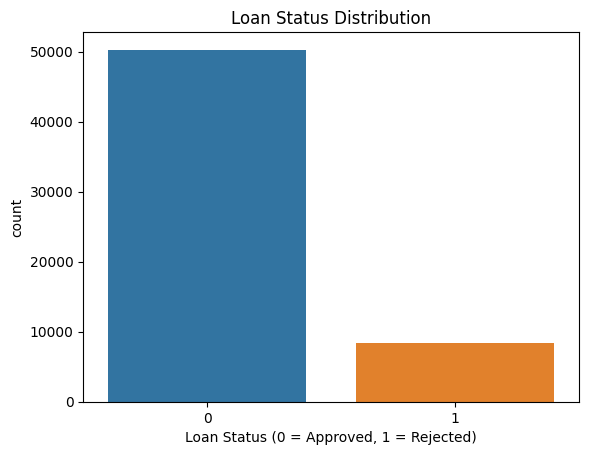

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64
loan_status
0    50295
1     8350
Name: count, dtype: int64


In [7]:
# Target distribution
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = Approved, 1 = Rejected)")
plt.show()

# Class balance
print(df['loan_status'].value_counts(normalize=True))

# Numbers
print(df['loan_status'].value_counts(normalize=False))

In [8]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)
print(missing)

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


In [9]:
categorical = df.select_dtypes(include='object').columns.tolist()
numerical = df.select_dtypes(include=['int64', 'float64']).drop(['loan_status', 'id'], axis=1).columns.tolist()
print("Categorical:", categorical)
print("Numerical:", numerical)

Categorical: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numerical: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


In [ ]:
df[numerical].describe()
df[numerical].hist(bins=30, figsize=(14, 10))
plt.suptitle("Histograms of Numerical Features")
plt.show()

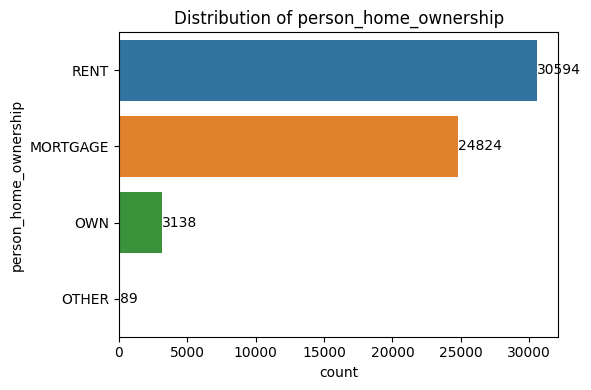

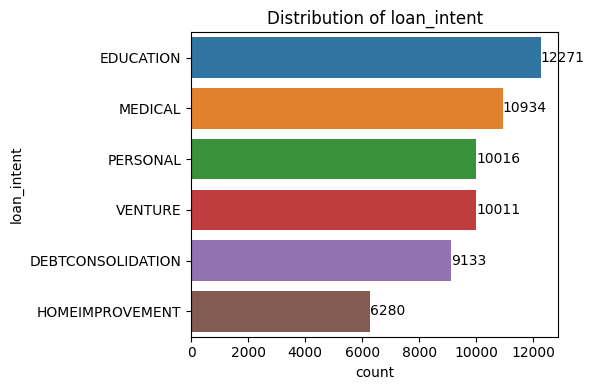

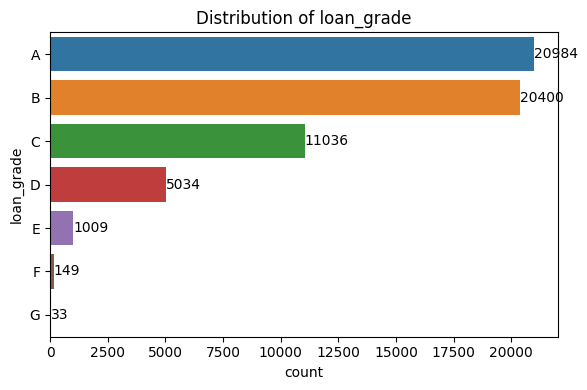

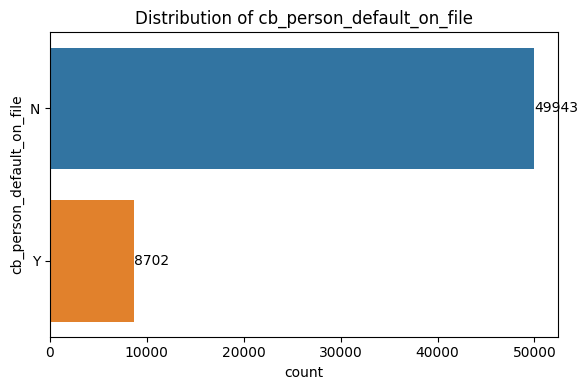

In [14]:
#Polished version
for col in categorical:
    plt.figure(figsize=(6,4))
    ax=sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.3, p.get_y() + p.get_height()/2, int(width), va='center')
    plt.tight_layout()
    plt.show()

loan_percent_income           0.378280
loan_int_rate                 0.338948
person_income                -0.169956
loan_amnt                     0.144982
person_emp_length            -0.100428
cb_person_cred_hist_length   -0.003030
person_age                   -0.001130
dtype: float64


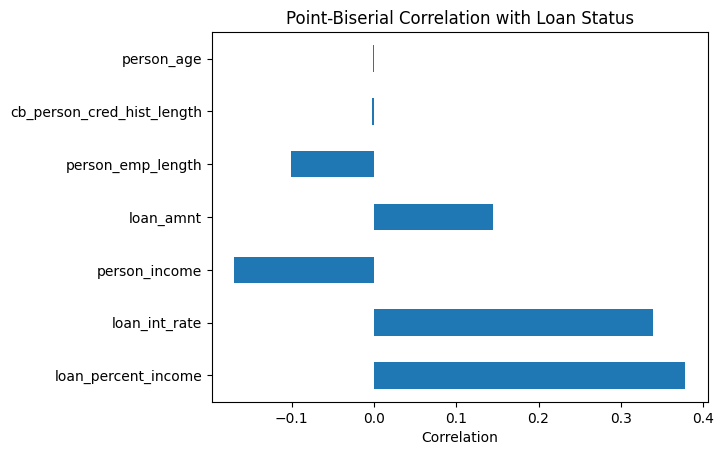

In [23]:
import numpy as np
from scipy.stats import pointbiserialr

corrs = {}
for col in numerical:
    corr, _ = pointbiserialr(df[col], df['loan_status'])
    corrs[col] = corr

corr_df = pd.Series(corrs).sort_values(key=abs, ascending=False)
print(corr_df)

# Plot
corr_df.plot(kind='barh', title="Point-Biserial Correlation with Loan Status")
plt.xlabel("Correlation")
plt.show()

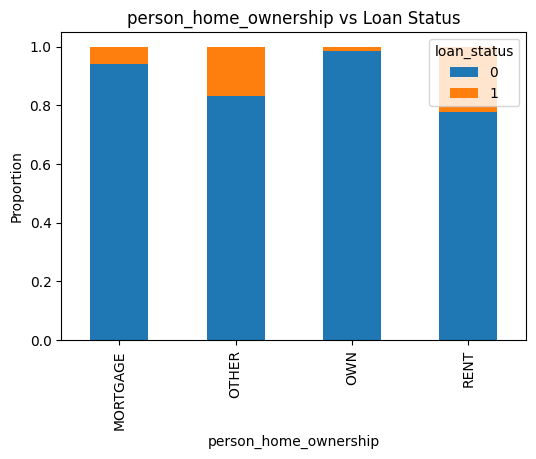

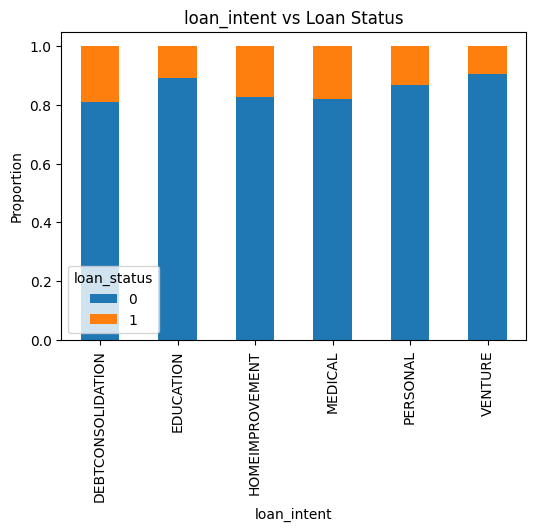

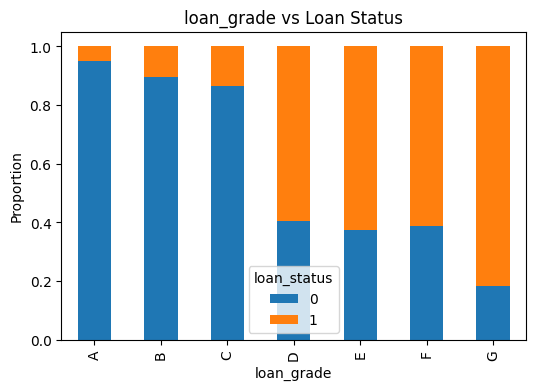

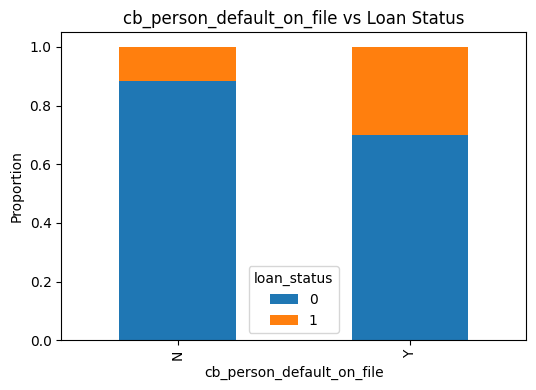

In [24]:
for col in categorical:
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index')
    ct.plot(kind='bar', stacked=True, title=f"{col} vs Loan Status", figsize=(6,4))
    plt.ylabel("Proportion")
    plt.show()

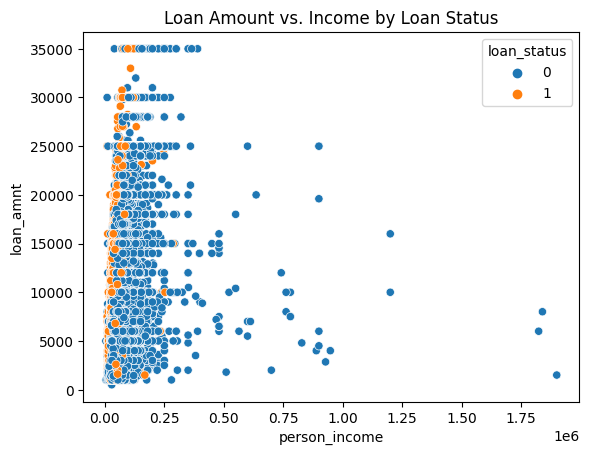

In [25]:
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.title("Loan Amount vs. Income by Loan Status")
plt.show()

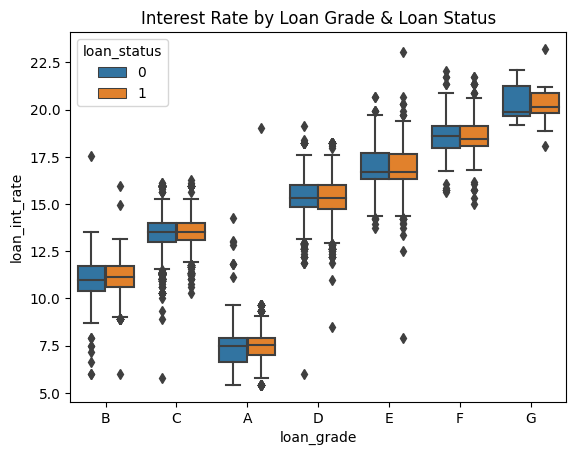

In [26]:
sns.boxplot(x='loan_grade', y='loan_int_rate', hue='loan_status', data=df)
plt.title("Interest Rate by Loan Grade & Loan Status")
plt.show()

In [27]:
from scipy.stats import zscore
z_scores = df[numerical].apply(zscore)
outliers = (z_scores.abs() > 3).sum()
print("Number of outliers per feature:\n", outliers)

Number of outliers per feature:
 person_age                    1010
person_income                  533
person_emp_length              627
loan_amnt                      345
loan_int_rate                   66
loan_percent_income            459
cb_person_cred_hist_length     492
dtype: int64


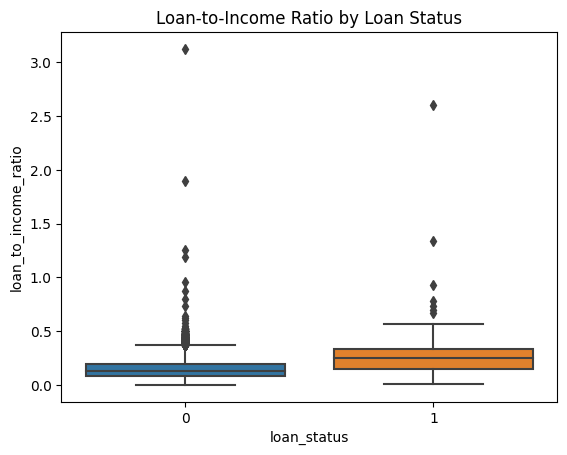

In [28]:
df['loan_to_income_ratio'] = df['loan_amnt'] / (df['person_income'] + 1)
sns.boxplot(x='loan_status', y='loan_to_income_ratio', data=df)
plt.title("Loan-to-Income Ratio by Loan Status")
plt.show()

In [29]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

In [ ]:
#!pip install scikit-learn==1.3.0 imbalanced-learn==0.11.0 --quiet
!pip install scikit-learn imbalanced-learn

INFO: pip is looking at multiple versions of imbalanced-learn to determine which version is compatible with other requirements. This could take a while.


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from sklearn.over_sampling import SMOTE
# from imblearn.over_sampling import RandomOverSampler

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

ModuleNotFoundError: No module named 'sklearn.over_sampling'

In [ ]:
# Create pipeline
model_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    # ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42,
        scale_pos_weight=6,  # Because class imbalance ~ 86:14
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Train the model
model_pipeline.fit(X_train, y_train)

In [ ]:
# Predictions
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))